In [1]:
# First I import basic libraries that I need to data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Then I import the data set
df = pd.read_csv('personality_dataset.csv')

# In here I expore the data set using following lines
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())

#I Drop duplicates because It affects to accuracy of the model
df.drop_duplicates(inplace=True)

# Here I replace missing values in numerical columns(using median for numerical to handle potential outliers)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Replace missing categorical values with the mode
categorical_cols = ['Stage_fear', 'Drained_after_socializing']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB
None
       Time_spent_Alone  Social_event_attendance  Going_outside  \
count       2837.000000              2838.000000    2834.000000   
mean           4.505816                 3.963354       3.000000   
std            3.479192                 2.903827       2.247327   
min    

C:\Users\MIKAZ-PC\AppData\Local\Temp\ipykernel_41204\1393075381.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\MIKAZ-PC\AppData\Local\Temp\ipykernel_41204\1393075381.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

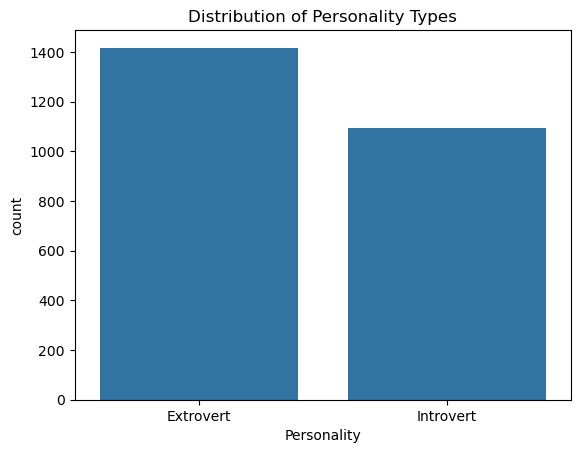

In [13]:
# Visualize class distribution (Imbalance check)
sns.countplot(data=df, x='Personality')
plt.title('Distribution of Personality Types')

plt.savefig('class_imbalance.png', dpi=300, bbox_inches='tight')  # <-- ADD THIS
plt.show()

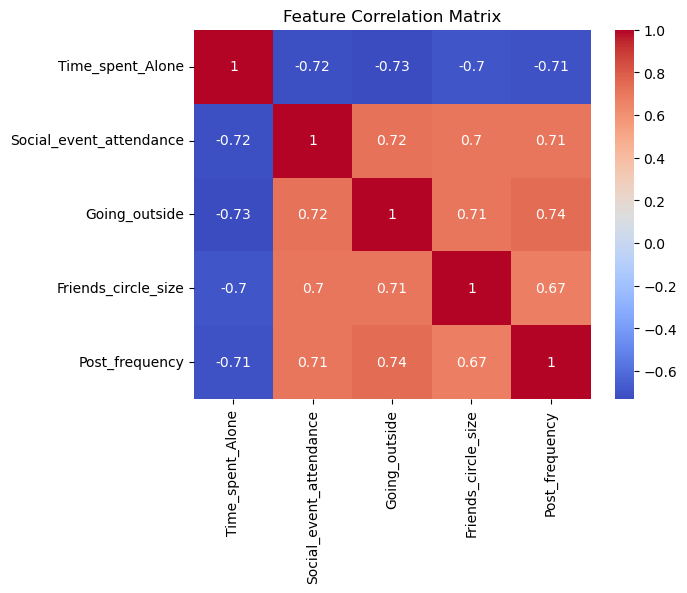

In [12]:
# Visualize correlations for numerical features
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')

plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')  # <-- ADD THIS
plt.show()


In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# Separate features (X) and target (y)
X = df.drop('Personality', axis=1)
y = df['Personality']

# 1. Encoding the Target Variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y) # Extrovert -> 0, Introvert -> 1 (or vice versa)

# 2. Transformation, Scaling & Encoding Features
# We use ColumnTransformer to apply different preprocessing to numerical vs categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols) # drop='first' avoids multicollinearity
    ])

X_processed = preprocessor.fit_transform(X)


print(f"Final feature matrix shape: {X_processed.shape}")

Final feature matrix shape: (2512, 7)


In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

# 1. Data Splitting (Keeping your exact stratified setup)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 2. Define the Model Registry & Hyperparameter Grids
models_config = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [None, 10],
            'min_samples_split': [2, 5]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.1, 1.0, 10.0]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5]
        }
    },
    'Support Vector Machine': {
        'model': SVC(random_state=42),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'kernel': ['rbf', 'linear']
        }
    },
    'K-Nearest Neighbours': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance']
        }
    }
}

In [6]:
results = []
trained_estimators = {}

for name, config in models_config.items():
    print(f"⏳ Tuning & Training: {name}...")
    
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=3,
        scoring='f1_macro', # Keeping your original metric choice
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    # Store the tuned model
    best_model = grid.best_estimator_
    trained_estimators[name] = best_model
    
    # Evaluate on unseen Test Data
    y_pred = best_model.predict(X_test)
    
    results.append({
        'Model': name,
        'CV F1 (Train)': round(grid.best_score_, 4),
        'Test Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Test F1 (Macro)': round(f1_score(y_test, y_pred, average='macro'), 4),
        'Best Params': grid.best_params_
    })

# Generate Leaderboard sorted by Test F1
leaderboard = pd.DataFrame(results).sort_values(by='Test F1 (Macro)', ascending=False)
print("\n--- 🏆 MODEL LEADERBOARD ---")
display(leaderboard)

⏳ Tuning & Training: Random Forest...
⏳ Tuning & Training: Logistic Regression...
⏳ Tuning & Training: Gradient Boosting...
⏳ Tuning & Training: Support Vector Machine...
⏳ Tuning & Training: K-Nearest Neighbours...

--- 🏆 MODEL LEADERBOARD ---


,Model,CV F1 (Train),Test Accuracy,Test F1 (Macro),Best Params
4,K-Nearest Neighbours,0.9257,0.9165,0.9156,"{'n_neighbors': 7, 'weights': 'uniform'}"
0,Random Forest,0.9268,0.9145,0.9136,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."
1,Logistic Regression,0.9288,0.9145,0.9136,{'C': 0.1}
2,Gradient Boosting,0.9293,0.9145,0.9136,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
3,Support Vector Machine,0.9293,0.9145,0.9136,"{'C': 0.1, 'kernel': 'rbf'}"


In [7]:
# Grab the #1 model dynamically
champion_name = leaderboard.iloc[0]['Model']
champion_model = trained_estimators[champion_name]

print(f"🥇 Champion Model Selected: {champion_name}\n")

y_champ_pred = champion_model.predict(X_test)
print(classification_report(y_test, y_champ_pred, target_names=label_encoder.classes_))

🥇 Champion Model Selected: K-Nearest Neighbours

              precision    recall  f1-score   support

   Extrovert       0.95      0.90      0.92       284
   Introvert       0.88      0.94      0.91       219

    accuracy                           0.92       503
   macro avg       0.91      0.92      0.92       503
weighted avg       0.92      0.92      0.92       503



In [8]:
import joblib

# 1. Save the shared preprocessor (Required to feed raw data into ANY of the models)
joblib.dump(preprocessor, 'preprocessor.pkl')
print("💾 Shared preprocessor saved -> 'preprocessor.pkl'\n")

print("--- SAVING INDIVIDUAL MODEL ARTIFACTS ---")

# 2. Loop through the dictionary of trained models
for model_name, model_object in trained_estimators.items():
    
    # Turn "Support Vector Machine" into "support_vector_machine"
    clean_slug = model_name.lower().replace(' ', '_').replace('-', '_')
    file_name = f"model_{clean_slug}.pkl"
    
    joblib.dump(model_object, file_name)
    print(f"✅ Saved: {model_name:<25} -> {file_name}")

💾 Shared preprocessor saved -> 'preprocessor.pkl'

--- SAVING INDIVIDUAL MODEL ARTIFACTS ---
✅ Saved: Random Forest             -> model_random_forest.pkl
✅ Saved: Logistic Regression       -> model_logistic_regression.pkl
✅ Saved: Gradient Boosting         -> model_gradient_boosting.pkl
✅ Saved: Support Vector Machine    -> model_support_vector_machine.pkl
✅ Saved: K-Nearest Neighbours      -> model_k_nearest_neighbours.pkl


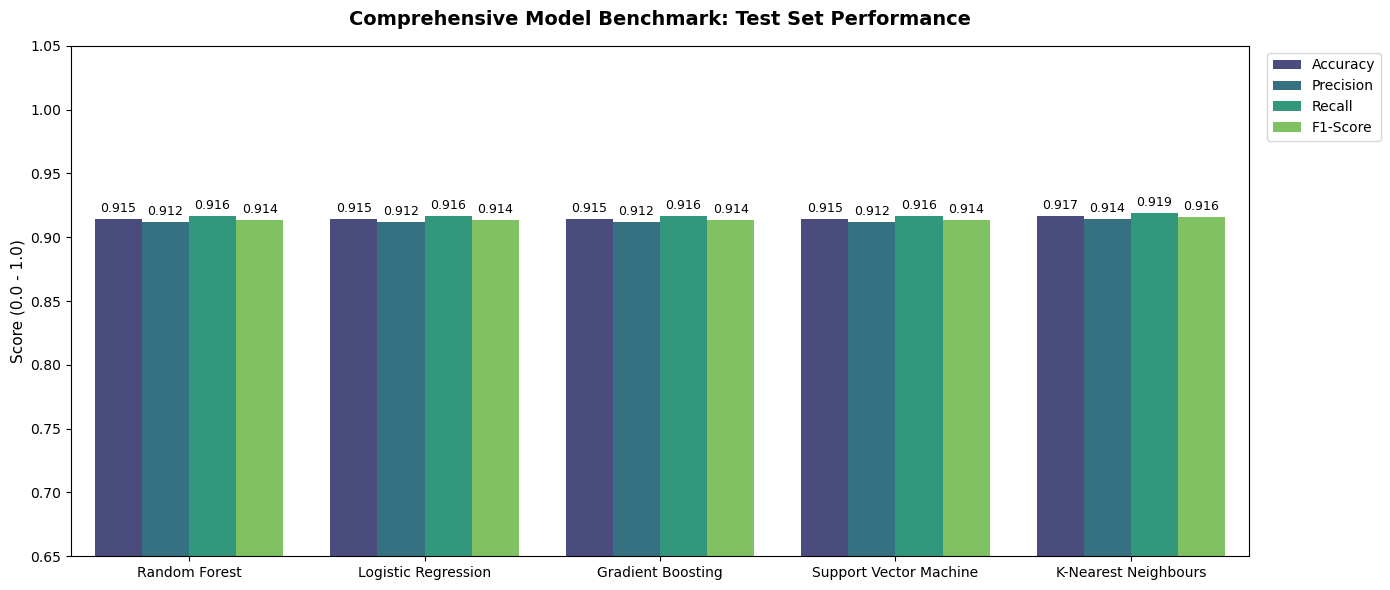

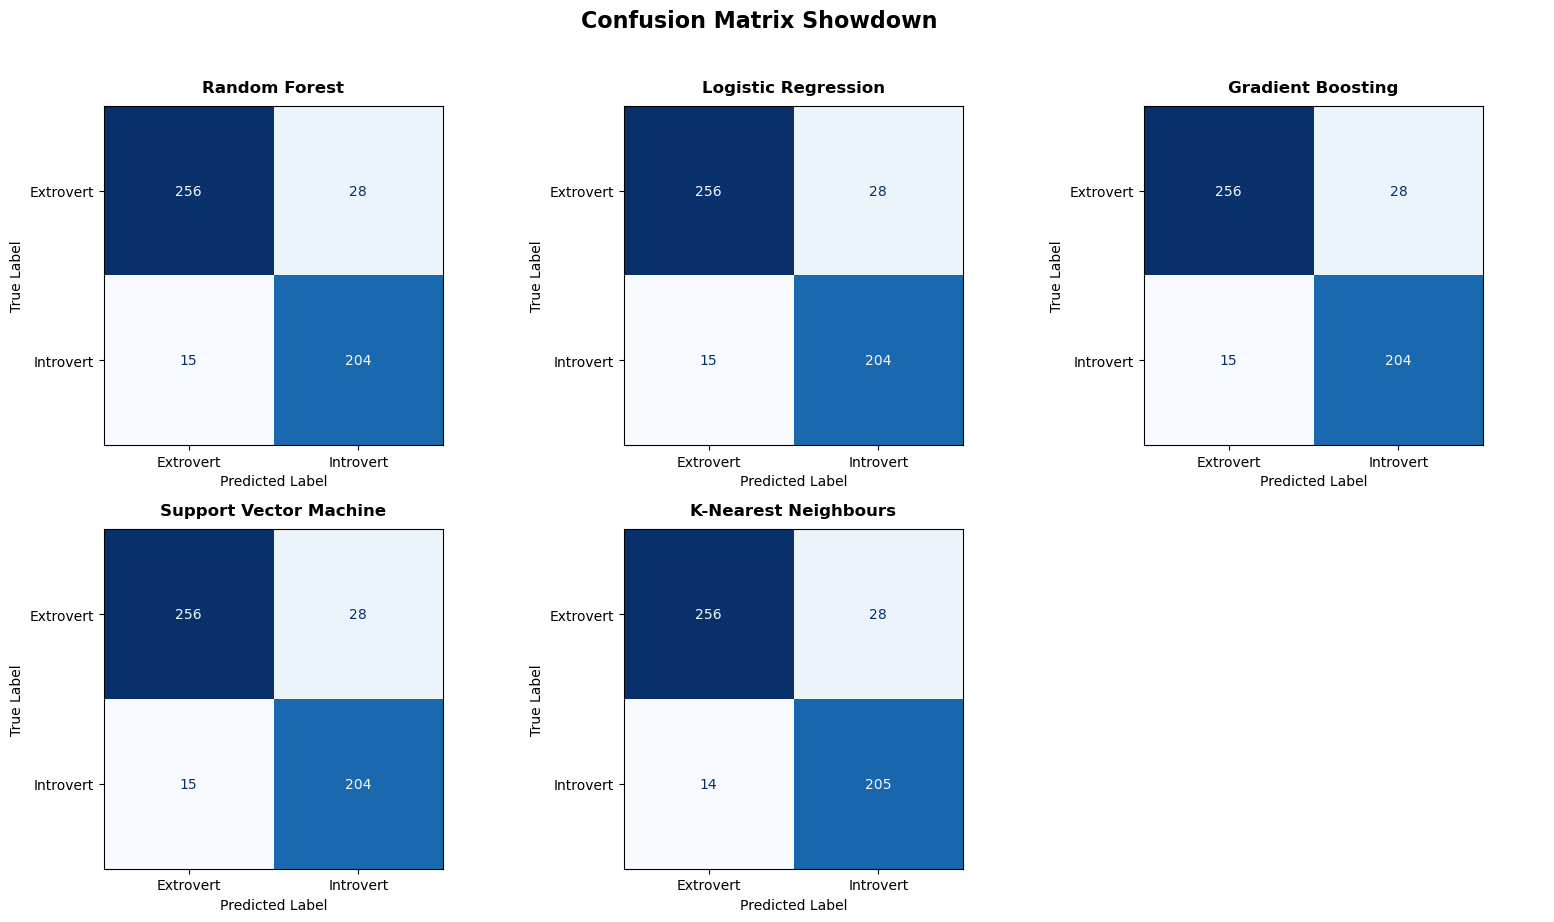

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

# ==========================================
# PART 1: COLLECT ALL METRICS INTO A TABLE
# ==========================================
detailed_metrics = []

for name, model in trained_estimators.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    # average='macro' calculates metrics for both Introvert & Extrovert equally
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    
    detailed_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

df_metrics = pd.DataFrame(detailed_metrics)

# ==========================================
# PART 2: PLOT THE SCALAR METRICS (BAR CHART)
# ==========================================
# "Melt" the table so Seaborn can plot multiple metrics per model
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

plt.title('Comprehensive Model Benchmark: Test Set Performance', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Score (0.0 - 1.0)', fontsize=11)
plt.xlabel('')
plt.ylim(0.65, 1.05) # Zoomed in so tiny performance gaps are actually visible!

# Automatically print the exact numbers on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
plt.tight_layout()



plt.savefig('model_benchmark.png', dpi=300, bbox_inches='tight')  # <-- ADD THIS

plt.show()

# ==========================================
# PART 3: PLOT THE 5 CONFUSION MATRICES
# ==========================================
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes_flat = axes.flatten()

for i, (name, model) in enumerate(trained_estimators.items()):
    ax = axes_flat[i]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=label_encoder.classes_
    )
    # colorbar=False keeps the grid neat; cmap='Blues' is standard
    disp.plot(ax=ax, cmap='Blues', colorbar=False) 
    ax.set_title(name, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

# We have 5 models, but a 2x3 grid has 6 spots. Turn off the blank 6th frame:
axes_flat[5].axis('off')

plt.suptitle('Confusion Matrix Showdown', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')  # <-- ADD THIS
plt.show()